In [1]:
import numpy as np 
import h5py
from pathlib import Path 
import IPython.display as ipd 
import pickle 
%matplotlib inline 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats
# import src.statsmodels as statsmodels 
import copy
import statsmodels.api as sm
from statsmodels.formula.api import ols


In [4]:
model = "word_task_v10_main_feature_gain_config_latest_ckpt"

analysis_dir = Path(f"/om/scratch/Thu/imgriff/binaural_unit_activations_for_anova/{model}")
anova_results = list(analysis_dir.glob("*.npz"))
anova_results = [result for result in anova_results if "jsin" in result.stem]

h5_fn = analysis_dir / f"{model}_model_activations_0dB_time_avg.h5"

h5 = h5py.File(h5_fn, "r") 
print(h5.keys())
# for key in h5.keys():
    # print(key, h5[key].shape)
target_f0s = h5["target_f0"][:]
target_locs = h5["target_loc"][:]
# h5.close()
valid_ixs = ~np.isnan(target_f0s)

target_f0s = target_f0s[valid_ixs]
target_locs = target_locs[valid_ixs]
target_words = h5["target_word_int"][valid_ixs]
target_talkers = h5["target_talker_id"][valid_ixs]
unique_word_int = np.unique(target_words)
unique_talker_int = np.unique(target_talkers)

<KeysViewHDF5 ['cochleagram_target', 'conv_block_0_relu_target', 'conv_block_1_relu_target', 'conv_block_2_relu_target', 'conv_block_3_relu_target', 'conv_block_4_relu_target', 'conv_block_5_relu_target', 'conv_block_6_relu_target', 'layer_names', 'relufc_target', 'target_f0', 'target_loc', 'target_talker_id', 'target_word_int', 'tested_azims']>


# Plot distribution of features in stimuli 

776
Optimal number of bins: 15
431


Text(0.5, 1.0, 'Talker distribution')

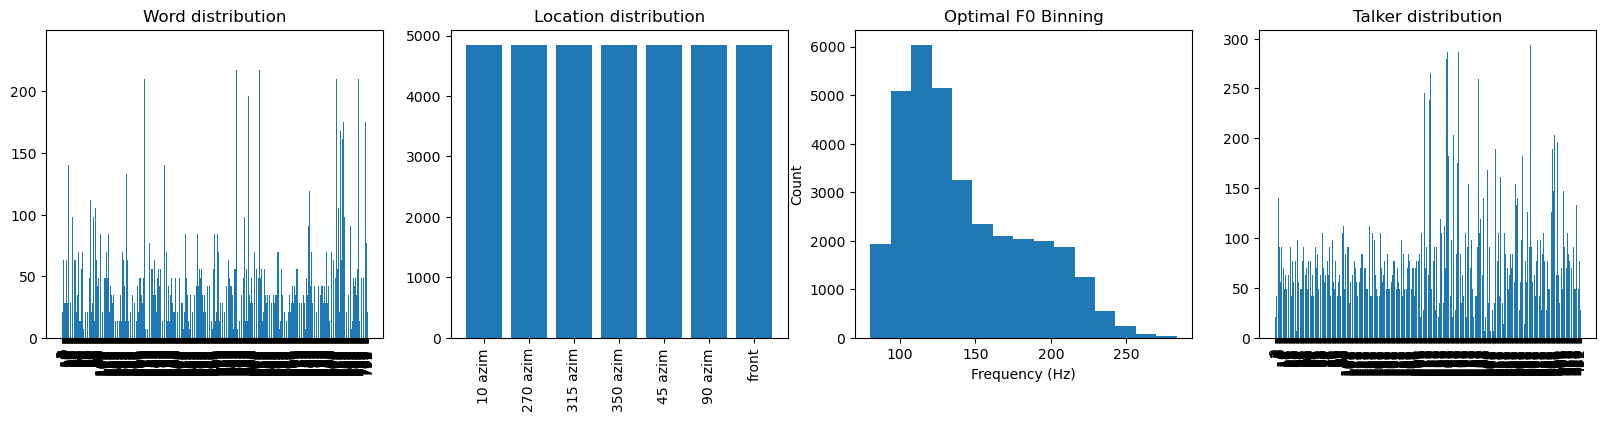

In [8]:
plt.figure(figsize=(20, 4))
plt.subplot(141)
words, count = np.unique(target_words, return_counts=True)
plt.bar(np.arange(len(count)), count)
print(len(words))
plt.xticks(np.arange(len(count)), words.astype('int'), rotation=90);
plt.title('Word distribution')

### get binning for location classes 

#  
unique_locations = np.unique(target_locs, axis=0).astype(int)
# print(unique_locations)
loc_list = np.zeros(len(target_locs), dtype=object)
for loc in unique_locations:
    loc_ixs = np.where(np.all(target_locs == loc, axis=1))[0]
    azim, elev = loc
    if elev == 0 and azim == 0:
        loc_list[loc_ixs] = 'front'
    elif elev == 0:
        loc_list[loc_ixs] = f"{azim} azim"
    elif azim == 0:
        loc_list[loc_ixs] = f"{elev} elev"

plt.subplot(142)
locs, count = np.unique(loc_list, return_counts=True)
plt.bar(np.arange(len(count)), count)
plt.xticks(np.arange(len(locs)), locs, rotation=90);
plt.title('Location distribution')


### get binning for pitch classes 
def optimal_bin_count(data, min_bins=1, max_bins=50):
    # Calculate the Freedman-Diaconis bin width
    q25, q75 = np.percentile(data, [25, 75])
    bin_width = 2 * (q75 - q25) * len(data) ** (-1/3)
    bin_width = max(bin_width, 1e-5)  # Ensure bin width is not zero

    # Calculate the range of bin counts to test
    data_range = np.ptp(data)
    min_bins = max(min_bins, int(np.ceil(data_range / bin_width)))
    max_bins = min(max_bins, int(np.floor(data_range / bin_width)))

    best_bin_count = min_bins
    best_variance = float('inf')

    # Iterate over the range of bin counts
    for bins in range(min_bins, max_bins + 1):
        counts, _ = np.histogram(data, bins=bins)
        variance = np.var(counts)
        if variance < best_variance:
            best_variance = variance
            best_bin_count = bins

    return best_bin_count

plt.subplot(143)
# Example usage with target_f0s data
# target_f0s = np.random.rand(100) * 100  # Replace with your actual data
optimal_bins = 15 #  optimal_bin_count(target_f0s)
print(f"Optimal number of bins: {optimal_bins}")

# Plot the histogram with the optimal number of bins
plt.hist(target_f0s, bins=optimal_bins)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Count')
plt.title('Optimal F0 Binning')


plt.subplot(144)
talkers, count = np.unique(target_talkers, return_counts=True)
plt.bar(np.arange(len(count)), count)
print(len(talkers))
plt.xticks(np.arange(len(count)), talkers.astype('int'), rotation=90);
plt.title('Talker distribution')




In [9]:
results_dict = {}

for result in anova_results:
    layer_name = "_".join(result.stem.split("_")[:3])
    if layer_name not in results_dict:
        results_dict[layer_name] = {"prop_var_exp": [], 'ssq_per_unit':[]}
    results = np.load(result)
    results_dict[layer_name]["prop_var_exp"].append(results['prop_var_per_unit'])
    results_dict[layer_name]["ssq_per_unit"].append(results['ssq_per_unit'])

## Concat results across all units
for layer in results_dict.keys():
    results_dict[layer]["prop_var_exp"] = np.concatenate(results_dict[layer]["prop_var_exp"])
    results_dict[layer]["ssq_per_unit"] = np.concatenate(results_dict[layer]["ssq_per_unit"])
    print(layer, results_dict[layer]["prop_var_exp"].shape, results_dict[layer]["ssq_per_unit"].shape)

conv_block_5 (3072, 4) (3072, 4)
conv_block_2 (2560, 4) (2560, 4)
conv_block_6 (4096, 4) (4096, 4)
conv_block_1 (960, 4) (960, 4)
conv_block_0 (224, 4) (224, 4)
conv_block_3 (256, 4) (256, 4)


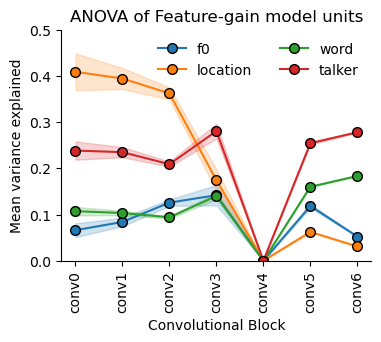

In [92]:
## get info for lineplot 
fig, ax = plt.subplots(figsize=(4,3))

var_thresh = 0.1


for ix, feature in enumerate(['f0', 'location', 'word', 'talker']):
    mean_var_exp = np.zeros(len(results_dict)+1)
    std_var_exp = np.zeros(len(results_dict)+1)
    for layer, data in results_dict.items():
        # print(layer)
        layer_ix = int(layer.split("_")[-1])
        n = data['prop_var_exp'].shape[0]
        mean_var_exp[layer_ix] = np.nanmean(data['prop_var_exp'][:,ix])
        std_var_exp[layer_ix] = 2 *  np.nanstd(data['prop_var_exp'][:,ix]) / np.sqrt(n)
        
    ax.plot(
        np.arange(len(results_dict)+1),
        mean_var_exp,
        label=feature,
        color=f"C{ix}",
        marker='o',
        markersize=7,
        markeredgecolor='k',
        markeredgewidth=1,
        )
    ax.fill_between(
        np.arange(len(results_dict)+1),
        mean_var_exp+std_var_exp,
        mean_var_exp-std_var_exp,
        # yerr=std_var_exp,
        # fmt='o',
        # label=feature,
        color=f"C{ix}",
        alpha=0.2,
        # markersize=7,
        # markeredgecolor='k',
        # markeredgewidth=1,
        )

ax.set_ylabel(f'Mean variance explained')
# plt.xlabel('Convolutional Block')
xtick_labels = [f"conv{i}" for i in range(len(results_dict)+1)]
ax.set_title(f"ANOVA of Feature-gain model units", y=1)
ax.legend(frameon=False, ncol=2, loc='upper right')

ax.set_xticks(np.arange(len(results_dict)+1))
ax.set_xticklabels(xtick_labels, rotation=90)
ax.set_xlabel('Convolutional Block')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, 0.5)
plt.subplots_adjust(wspace=0.3)


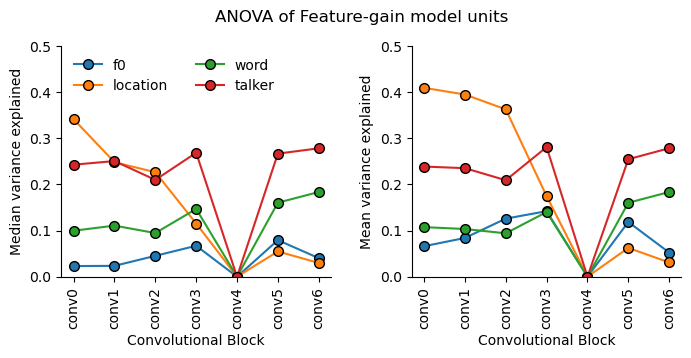

In [57]:
## get info for lineplot 
fig, ax = plt.subplots(1,2, figsize=(8,3))

var_thresh = 0.1


for ix, feature in enumerate(['f0', 'location', 'word', 'talker']):
    median_var_exp = np.zeros(len(results_dict)+1)
    mean_var_exp = np.zeros(len(results_dict)+1)
    for layer, data in results_dict.items():
        # print(layer)
        layer_ix = int(layer.split("_")[-1])
        median_var_exp[layer_ix] = np.nanmedian(data['prop_var_exp'][:,ix])
        mean_var_exp[layer_ix] = np.nanmean(data['prop_var_exp'][:,ix])
        
    ax[0].plot(
        np.arange(len(results_dict)+1),
        median_var_exp,
        label=feature,
        color=f"C{ix}",
        marker='o',
        markersize=7,
        markeredgecolor='k',
        markeredgewidth=1,
        )
    ax[0].set_ylabel(f'Median variance explained')

    ax[1].plot(
        np.arange(len(results_dict)+1),
        mean_var_exp,
        label=feature,
        color=f"C{ix}",
        marker='o',
        markersize=7,
        markeredgecolor='k',
        markeredgewidth=1,
        )
    ax[1].set_ylabel(f'Mean variance explained')

# plt.xlabel('Convolutional Block')
xtick_labels = [f"conv{i}" for i in range(len(results_dict)+1)]
plt.suptitle(f"ANOVA of Feature-gain model units", y=1)
ax[0].legend(frameon=False, ncol=2, loc='upper left')

for ax in ax:
    ax.set_xticks(np.arange(len(results_dict)+1))
    ax.set_xticklabels(xtick_labels, rotation=90)
    ax.set_xlabel('Convolutional Block')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, 0.5)
plt.subplots_adjust(wspace=0.3)
